In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [283]:
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [284]:
df.shape

(891, 12)

In [285]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

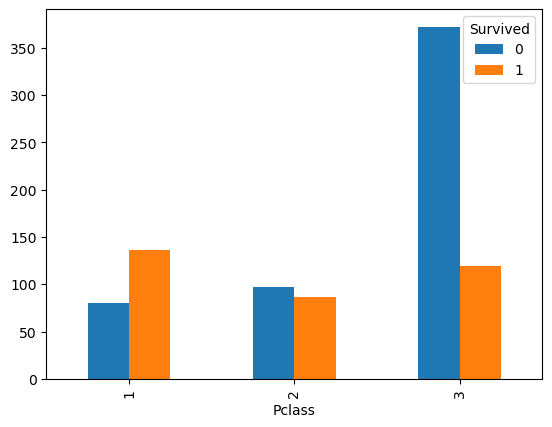

In [286]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')

In [287]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

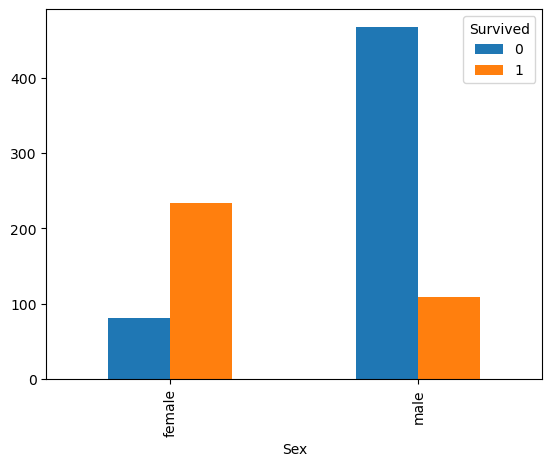

In [288]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')

In [289]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

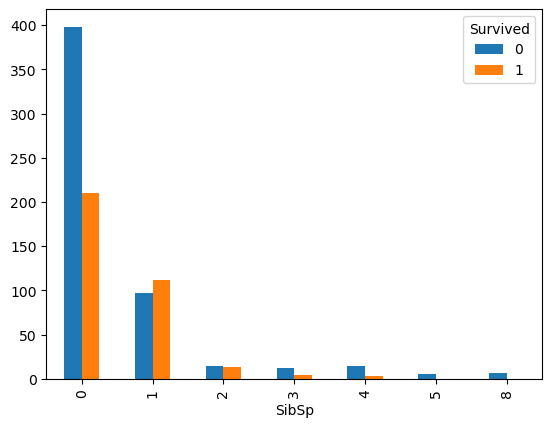

In [290]:
pd.crosstab(df['SibSp'], df['Survived']).plot(kind='bar')

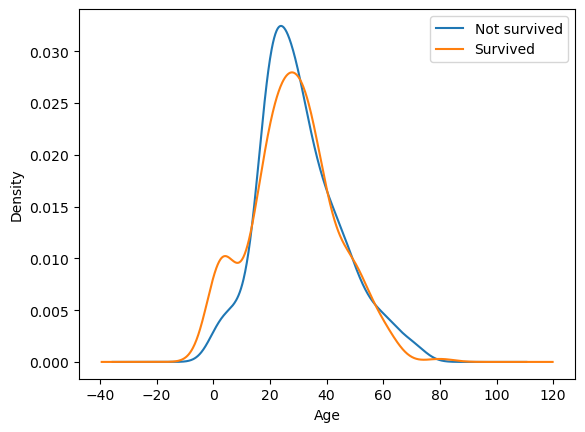

In [291]:
df[df['Survived'] == 0]['Age'].plot(kind='kde', label='Not survived')
df[df['Survived'] == 1]['Age'].plot(kind='kde', label='Survived')
plt.xlabel('Age')
plt.legend()

In [292]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

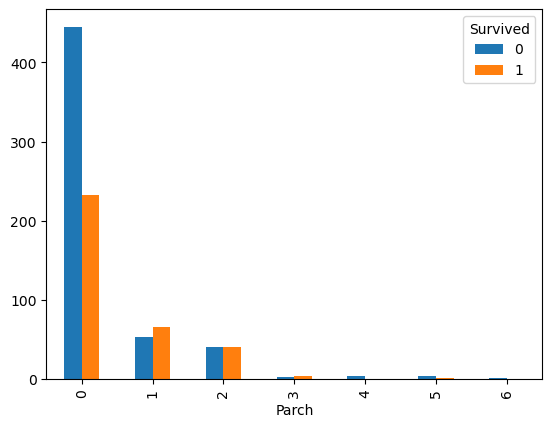

In [293]:
pd.crosstab(df['Parch'], df['Survived']).plot(kind='bar')

In [294]:
df['TicketGroupSize'] = df.groupby('Ticket')['Ticket'].transform('count')

<Axes: xlabel='TicketGroupSize'>

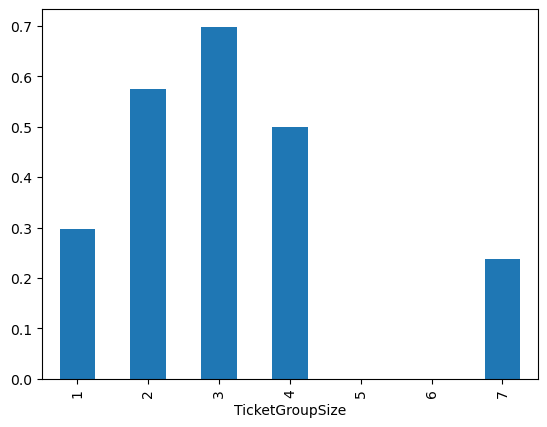

In [295]:
df.groupby('TicketGroupSize')['Survived'].mean().plot(kind='bar')

In [296]:
df['Cabin'].value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [297]:
df.groupby('Cabin')['Cabin'].transform('count')

0      NaN
1      1.0
2      NaN
3      2.0
4      NaN
      ... 
886    NaN
887    1.0
888    NaN
889    1.0
890    NaN
Name: Cabin, Length: 891, dtype: float64

In [298]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

<Axes: xlabel='HasCabin'>

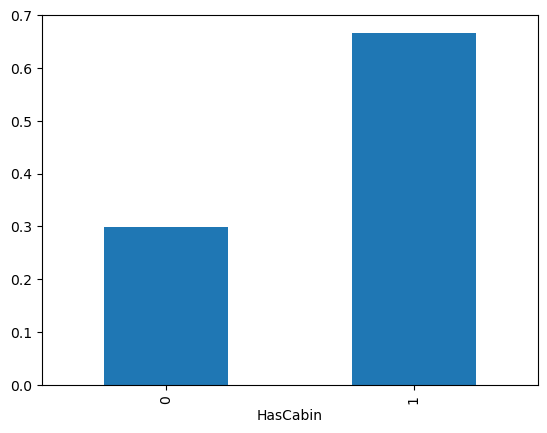

In [299]:
df.groupby('HasCabin')['Survived'].mean().plot(kind='bar')

In [300]:
df['Deck'] = df['Cabin'].str[0]

In [301]:
df['Deck'] = df['Deck'].fillna('unknown')

<Axes: xlabel='Deck'>

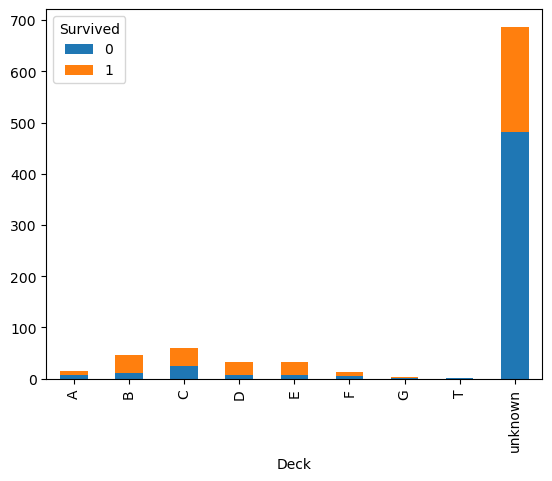

In [302]:
pd.crosstab(df['Deck'], df['Survived']).plot(kind='bar', stacked=True)

In [303]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

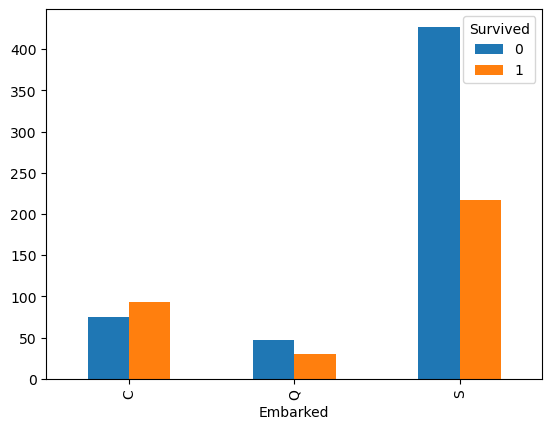

In [304]:
pd.crosstab(df['Embarked'], df['Survived']).plot(kind='bar')

In [305]:
df.isna().sum()

PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                177
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             2
TicketGroupSize      0
HasCabin             0
Deck                 0
dtype: int64

In [306]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [307]:
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

In [308]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [311]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df['Sex_male'] = df['Sex_male'].astype(int)

In [312]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [313]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [314]:
df

,Survived,Pclass,Age,Fare,Embarked,TicketGroupSize,HasCabin,Deck,Sex_male,FamilySize,IsAlone
0,0,3,22.000000,7.2500,S,1,0,unknown,1,2,0
1,1,1,38.000000,71.2833,C,1,1,C,0,2,0
2,1,3,26.000000,7.9250,S,1,0,unknown,0,1,1
3,1,1,35.000000,53.1000,S,2,1,C,0,2,0
4,0,3,35.000000,8.0500,S,1,0,unknown,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,13.0000,S,1,0,unknown,1,1,1
887,1,1,19.000000,30.0000,S,1,1,B,0,1,1
888,0,3,29.699118,23.4500,S,2,0,unknown,0,4,0
889,1,1,26.000000,30.0000,C,1,1,C,1,1,1


In [316]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = pd.get_dummies(df, columns=['Deck'], drop_first=True)

In [321]:
df[['Embarked_Q', 'Embarked_S', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_unknown']] = df[['Embarked_Q', 'Embarked_S', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_unknown']].astype(int)

In [322]:
df

,Survived,Pclass,Age,Fare,TicketGroupSize,HasCabin,Sex_male,FamilySize,IsAlone,Embarked_Q,Embarked_S,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_unknown
0,0,3,22.000000,7.2500,1,0,1,2,0,0,1,0,0,0,0,0,0,0,1
1,1,1,38.000000,71.2833,1,1,0,2,0,0,0,0,1,0,0,0,0,0,0
2,1,3,26.000000,7.9250,1,0,0,1,1,0,1,0,0,0,0,0,0,0,1
3,1,1,35.000000,53.1000,2,1,0,2,0,0,1,0,1,0,0,0,0,0,0
4,0,3,35.000000,8.0500,1,0,1,1,1,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,13.0000,1,0,1,1,1,0,1,0,0,0,0,0,0,0,1
887,1,1,19.000000,30.0000,1,1,0,1,1,0,1,1,0,0,0,0,0,0,0
888,0,3,29.699118,23.4500,2,0,0,4,0,0,1,0,0,0,0,0,0,0,1
889,1,1,26.000000,30.0000,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0


In [324]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'TicketGroupSize', 'HasCabin',
       'Sex_male', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S',
       'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T',
       'Deck_unknown'],
      dtype='object')

In [326]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['Age', 'Fare']

In [327]:
df[cols] = scaler.fit_transform(df[cols])

In [342]:
corr = df.corr(numeric_only=True).round(2)

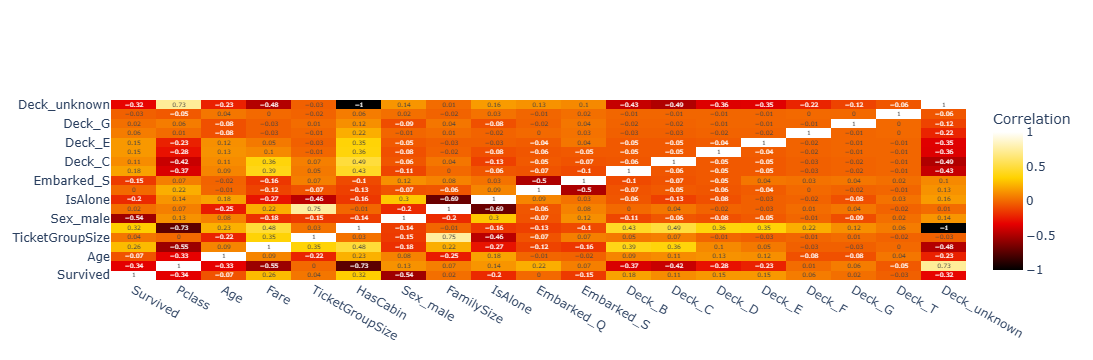

In [344]:
import plotly.graph_objects as go

go.Figure(
    go.Heatmap(
        x=corr.columns,
        y=corr.index,
        z=corr.values,
        colorscale='Hot',
        colorbar=dict(title="Correlation"),
        texttemplate= "%{z}"
    )
)

In [350]:
# Pclass Fare HasCabin Sex_male IsAlone Deck_unknown
X = df[['Pclass', 'Fare', 'HasCabin', 'Sex_male', 'IsAlone','Deck_unknown']]
y = df['Survived']

In [351]:
X

,Pclass,Fare,HasCabin,Sex_male,IsAlone,Deck_unknown
0,3,-0.502445,0,1,0,1
1,1,0.786845,1,0,0,0
2,3,-0.488854,0,0,1,1
3,1,0.420730,1,0,0,0
4,3,-0.486337,0,1,1,1
...,...,...,...,...,...,...
886,2,-0.386671,0,1,1,1
887,1,-0.044381,1,0,1,0
888,3,-0.176263,0,0,0,1
889,1,-0.044381,1,1,1,0


In [352]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [353]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [357]:
y_train

6      0
718    0
685    0
73     0
882    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 596, dtype: int64

In [359]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0).fit(X, y)

In [361]:
y_pred = model.predict(X_test)

In [363]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.7898305084745763
[[149  26]
 [ 36  84]]


In [364]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       175
           1       0.76      0.70      0.73       120

    accuracy                           0.79       295
   macro avg       0.78      0.78      0.78       295
weighted avg       0.79      0.79      0.79       295



In [366]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [367]:
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # expand until all leaves are pure
    random_state=42,
    class_weight='balanced'  # handle class imbalance
)

In [368]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [369]:
y_pred = rf_model.predict(X_test)

In [370]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7898305084745763
